<a href="https://colab.research.google.com/github/BheatrizNogueira/pythoncalculadora/blob/main/Lecture_3_Regression_Model_Group8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 3/Exercise 2 - Regression Model

**Course:** Introduction to Machine Learning Applications for Sustainability Research  
**Professors:** Lucas Zanon and Tiago Sigahi  
**Group:** Group 8  
**Group members:** Beatriz Nogueira, Felipe Perroni and Lucas Ladeira  
**Date:** July 16, 2026  

# Task 1 - Load the data and choose predictors

sdg3_lifee       0.457114
sdg9_articles    0.436590
sdg6_safewat     0.434548
sdg3_neonat     -0.431409
sdg4_preprim     0.429456
sdg5_familypl    0.428028
sdg9_patents     0.403450
sdg4_second      0.398582
sdg17_govex      0.396905
sdg9_intuse      0.393430
dtype: float64


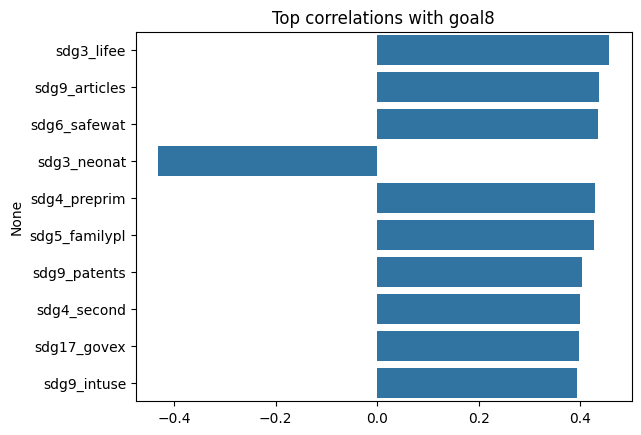

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "sdg8_dataset_final.xlsx"
base = pd.concat([pd.read_excel(FILE, sheet_name=0),
                  pd.read_excel(FILE, sheet_name=1)], ignore_index=True)
TARGET = "goal8"

num = base.select_dtypes("number").drop(columns=[TARGET, "year"], errors="ignore")
corr = num.corrwith(base[TARGET]).sort_values(key=abs, ascending=False)
print(corr.head(10))

sns.barplot(x=corr.head(10).values, y=corr.head(10).index)
plt.title("Top correlations with goal8"); plt.show()

### Answer

The indicators most strongly correlated with `goal8` were life expectancy (`sdg3_lifee`, 0.457), scientific articles (`sdg9_articles`, 0.437), access to safe water (`sdg6_safewat`, 0.435), and neonatal mortality (`sdg3_neonat`, -0.431).

These relationships make sense because health, innovation, education, and access to basic services are related to better social and economic conditions. Higher neonatal mortality is related to a lower SDG 8 score.

### Predictor selection strategy

We first identified the indicators with the strongest correlations with `goal8`. We also considered whether the indicators are related to decent work, economic growth, and sustainable development.

We compared four candidate predictors:
- `sdg3_lifee`: health and human development;
- `sdg9_articles`: scientific knowledge and innovation;
- `sdg1_lmicpov`: poverty and economic inclusion;
- `sdg5_lfpr`: women's participation in the labor market.

In [ ]:
candidates = ["sdg3_lifee", "sdg9_articles", "sdg1_lmicpov", "sdg5_lfpr"]

candidate_corr = base[candidates].corrwith(base[TARGET]).sort_values(key=abs, ascending=False)
print(candidate_corr)

sdg3_lifee       0.457114
sdg9_articles    0.436590
sdg1_lmicpov    -0.365499
sdg5_lfpr        0.252609
dtype: float64


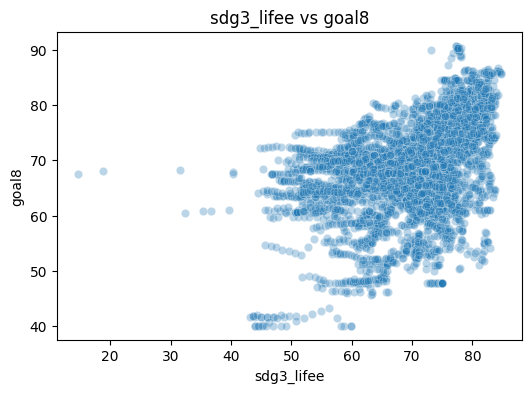

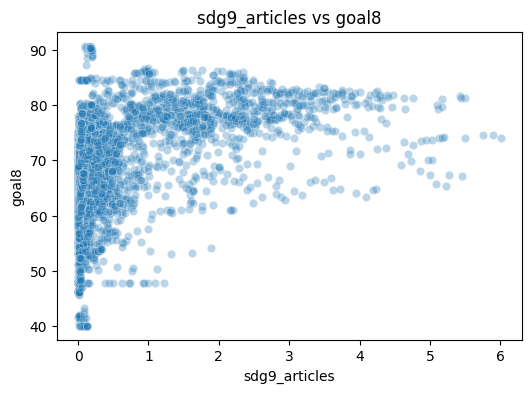

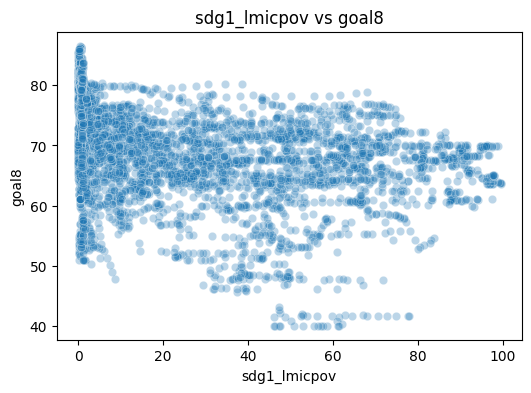

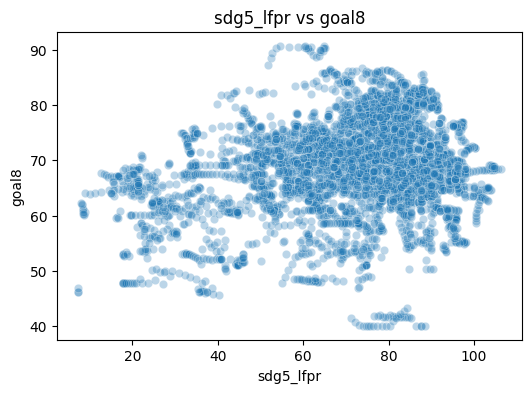

In [ ]:
for predictor in candidates:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=base, x=predictor, y=TARGET, alpha=0.3)
    plt.title(predictor + " vs goal8")
    plt.show()

In [ ]:
candidates = ["sdg3_lifee", "sdg9_articles", "sdg1_lmicpov", "sdg5_lfpr"]  # Defines the four candidate predictors.

candidate_corr = base[candidates].corrwith(base[TARGET]).sort_values(
    key=abs, ascending=False
)  # Calculates and sorts their correlations with goal8.

print(candidate_corr)  # Prints the correlations.

sdg3_lifee       0.457114
sdg9_articles    0.436590
sdg1_lmicpov    -0.365499
sdg5_lfpr        0.252609
dtype: float64


### Correlation between goal8 and candidate predictors

A predictor may be correlated with `goal8` and also correlated with another predictor. In this case, both predictors may provide similar information.

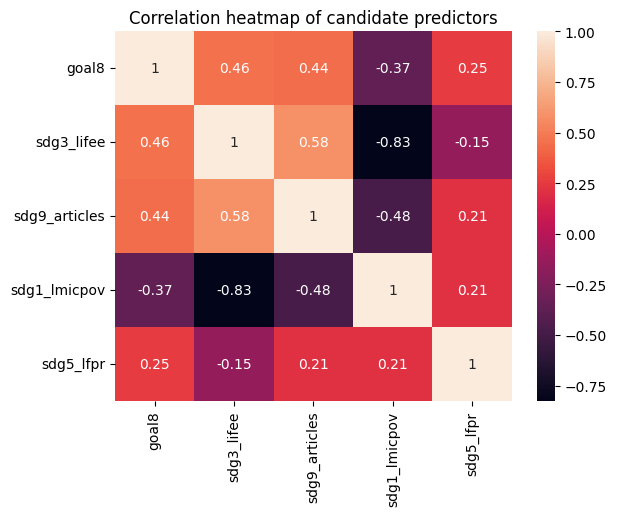

In [ ]:
sns.heatmap(base[[TARGET] + candidates].corr(), annot=True)  # Creates the correlation heatmap.
plt.title("Correlation heatmap of candidate predictors")  # Adds the title.
plt.show()  # Displays the heatmap.

### Final predictor choice

We selected `sdg3_lifee`, `sdg9_articles`, and `sdg5_lfpr`. These predictors represent three dimensions related to SDG 8: health and human development, innovation, and women's participation in the labor market.

Poverty (`sdg1_lmicpov`) was strongly correlated with life expectancy (-0.83), so the two indicators could provide similar information. We kept life expectancy because it had the strongest correlation with `goal8`.

###Your Turn

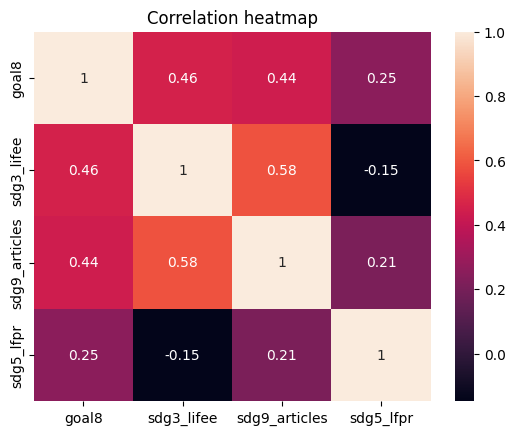

In [ ]:
p1 = "sdg3_lifee"
p2 = "sdg9_articles"
p3 = "sdg5_lfpr"

sns.heatmap(base[[TARGET, p1, p2, p3]].corr(), annot=True)
plt.title("Correlation heatmap")
plt.show()

The heatmap shows that none of the three selected predictors is strongly correlated with another predictor. The strongest correlation is between life expectancy (`sdg3_lifee`) and scientific articles (`sdg9_articles`), with a value of 0.58. This is a moderate positive correlation.

The correlations involving women's participation in the labor market (`sdg5_lfpr`) are weak, with values of -0.15 and 0.21. Therefore, the three predictors are not redundant and provide different information related to SDG 8.

#Task 2 - Simple linear regression

                            OLS Regression Results                            
Dep. Variable:                  goal8   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     1264.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          7.02e-245
Time:                        03:02:38   Log-Likelihood:                -15735.
No. Observations:                4607   AIC:                         3.147e+04
Df Residuals:                    4605   BIC:                         3.149e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.0383      0.875     43.463      0.0

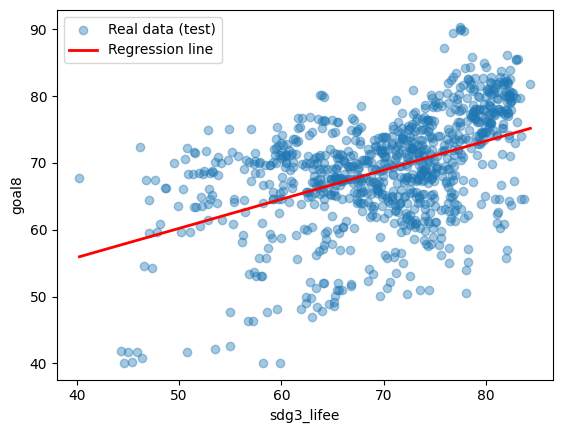

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.formula.api as smf

# one table used by all models below (same rows -> fair comparison)
dados = base[[TARGET, "sdg3_lifee", "sdg9_articles", "sdg5_lfpr"]].dropna()

# --- STATISTICAL ANALYSIS (statsmodels) ---
# The OLS method evaluates the statistical significance of the relationship between variables.
# KEY INDICATOR FROM SUMMARY: P-Value (column P>|t| in the 'sdg3_lifee' row)
# - If P > 0.05: The relationship between 'sdg3_lifee' and 'goal8' is not statistically significant.
# - If P <= 0.05: The relationship is statistically significant.
# SECONDARY INDICATOR: Coefficient (column 'coef')
# - Shows the association: each 1-unit increase in 'sdg3_lifee' is associated with a change
#   in 'goal8' equal to the coefficient value.
print(smf.ols("goal8 ~ sdg3_lifee", data=dados).fit().summary())

# --- DATA PREPARATION AND TRAINING (scikit-learn) ---
X = dados[["sdg3_lifee"]]
y = dados[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=3)

reg = LinearRegression().fit(X_train, y_train)
pred = reg.predict(X_test)

# --- PERFORMANCE INDICATORS (Error Metrics Evaluation) ---
# This trio (R², MAE, RMSE) provides complementary measures for evaluating regression models.

# INDICATOR 1: R² (Coefficient of Determination)
# - Measures the model's predictive performance. It can range from negative values to 1.0,
#   where 1.0 represents perfect predictions.
# - EXPLANATION: Indicates the proportion of variation in 'goal8' explained by the model.
# - Example: An R² of 0.60 means that the model explains 60% of the variation in 'goal8'.
print("R2  =", round(r2_score(y_test, pred), 3))

# INDICATOR 2: MAE (Mean Absolute Error)
# - Measures the average error directly in the target variable's scale (goal8).
# - EXPLANATION: On average, predictions differ from the actual 'goal8' values by the MAE.
# - It is less sensitive to large errors than RMSE and is easy to interpret.
print("MAE =", round(mean_absolute_error(y_test, pred), 2))

# INDICATOR 3: RMSE (Root Mean Squared Error)
# - Measures prediction error while giving more weight to large errors.
# - EXPLANATION: If RMSE is higher than MAE, some prediction errors may be relatively large.
# - It is useful when larger prediction errors are more important.
print("RMSE=", round(mean_squared_error(y_test, pred)**0.5, 2))

# plot the fitted line over the test data
# --- VISUAL ANALYSIS ---
# The chart plots real test data in blue and the regression model line in red.
# - Upward sloping line: Positive relationship between life expectancy and goal8.
# - Data point dispersion: Points farther from the red line have larger prediction errors.
order = np.argsort(X_test["sdg3_lifee"].values)

plt.scatter(
    X_test,
    y_test,
    alpha=0.4,
    label="Real data (test)")

plt.plot(
    X_test["sdg3_lifee"].values[order],
    pred[order],
    color="red",
    lw=2,
    label="Regression line")

plt.xlabel("sdg3_lifee")
plt.ylabel("goal8")
plt.legend()
plt.show()

# --- METRICS JUSTIFICATION ---
# The combination of R², MAE, and RMSE was selected because they provide complementary information:
# 1. R² assesses the proportion of variation in goal8 explained by the model.
# 2. MAE shows the average prediction error and is easy to interpret.
# 3. RMSE gives more weight to larger prediction errors.

### Answer

The slope of `sdg3_lifee` is 0.4416. This means that a one-unit increase in life expectancy is associated with an increase of about 0.44 points in `goal8`. The coefficient is statistically significant because its p-value is lower than 0.05.

However, life expectancy alone is not enough to predict `goal8`. The test R² is 0.227, which means that the model explains about 23% of the variation in `goal8`. Other indicators are also important.

###Your turn

                            OLS Regression Results                            
Dep. Variable:                  goal8   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     1199.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          9.42e-234
Time:                        03:02:38   Log-Likelihood:                -15761.
No. Observations:                4607   AIC:                         3.153e+04
Df Residuals:                    4605   BIC:                         3.154e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        66.7922      0.125    533.641

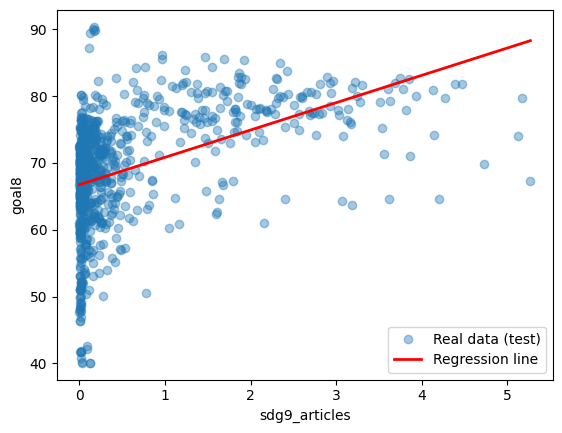

In [ ]:
# --- STATISTICAL ANALYSIS (statsmodels) ---
# KEY INDICATOR: P-Value (column P>|t| for 'sdg9_articles')
# - If P <= 0.05, the relationship is statistically significant.
# SECONDARY INDICATOR: Coef
# - Shows the association: how much 'goal8' changes when 'sdg9_articles'
#   increases by one unit.
print(smf.ols("goal8 ~ sdg9_articles", data=dados).fit().summary())

# --- DATA PREPARATION AND TRAINING (scikit-learn) ---
X = dados[["sdg9_articles"]]
y = dados[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=3
)

reg = LinearRegression().fit(X_train, y_train)
pred = reg.predict(X_test)

# --- PERFORMANCE INDICATORS (Error Metrics Evaluation) ---

# INDICATOR 1: R² (Coefficient of Determination)
# - Measures the proportion of variation in 'goal8' explained by the model.
print("R2  =", round(r2_score(y_test, pred), 3))

# INDICATOR 2: MAE (Mean Absolute Error)
# - Measures the average prediction error in the same scale as 'goal8'.
print("MAE =", round(mean_absolute_error(y_test, pred), 2))

# INDICATOR 3: RMSE (Root Mean Squared Error)
# - Measures prediction error while giving more weight to larger errors.
print("RMSE=", round(mean_squared_error(y_test, pred)**0.5, 2))

# --- VISUAL ANALYSIS ---
# The chart plots real test data in blue and the regression model line in red.
# - Downward sloping line: Negative relationship between poverty and goal8.
# - Points farther from the red line have larger prediction errors.
order = np.argsort(X_test["sdg9_articles"].values)

plt.scatter(
    X_test,
    y_test,
    alpha=0.4,
    label="Real data (test)"
)

plt.plot(
    X_test["sdg9_articles"].values[order],
    pred[order],
    color="red",
    lw=2,
    label="Regression line"
)

plt.xlabel("sdg9_articles")
plt.ylabel("goal8")
plt.legend()
plt.show()

# --- METRICS JUSTIFICATION ---
# The combination of R², MAE, and RMSE provides complementary information:
# 1. R² assesses the proportion of variation in goal8 explained by the model.
# 2. MAE shows the average prediction error and is easy to interpret.
# 3. RMSE gives more weight to larger prediction errors.

Using scientific articles (`sdg9_articles`) as the single predictor, the test R² was 0.198. This is lower than the test R² of 0.227 obtained with life expectancy (`sdg3_lifee`).

Therefore, life expectancy predicted `goal8` slightly better than scientific articles in our simple regression models. Scientific articles had a positive relationship with `goal8`, but they explained a smaller proportion of its variation.

#Task 3 - Multiple linear regression

In [ ]:

# 1) four-predictor model, to check significance
dados4 = base[  [TARGET, "sdg3_lifee", "sdg9_articles", "sdg5_lfpr", "sdg3_neonat"]].dropna()

# --- MULTIPLE LINEAR REGRESSION STATISTICAL SUMMARY (statsmodels) ---
# KEY INDICATOR 1: P-Values (column P>|t| for each predictor) -> Evaluates if a variable is a significant predictor (P <= 0.05).
# - Variables with P > 0.05 should be dropped because they do not provide a statistically relevant impact.
# KEY INDICATOR 2: Adj. R-squared (Adjusted R²) -> The most reliable global metric here. Unlike normal R²,
# Adjusted R² only increases if the new predictor actually improves the model, penalizing unnecessary variables.
print(smf.ols("goal8 ~ sdg3_lifee + sdg9_articles + sdg5_lfpr + sdg3_neonat",
              data=dados4).fit().summary())

# 2) keep the significant predictors and evaluate
# NOTE: 'sdg3_neonat' was dropped here because its P-Value was likely > 0.05 in step 1.
preds = ["sdg3_lifee", "sdg9_articles", "sdg5_lfpr"]
X = dados[preds]
y = dados[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

reg = LinearRegression().fit(X_train, y_train)
pred = reg.predict(X_test)

# --- PERFORMANCE EVALUATION FOR MULTIPLE PREDICTORS (scikit-learn) ---

# INDICATOR 1: R² (Coefficient of Determination)
# - Measures the joint capability of the three combined predictors ('sdg3_lifee', 'sdg9_articles', 'sdg5_lfpr')
#   to explain the total variance of 'goal8'.
print("R2  =", round(r2_score(y_test, pred), 3))

# INDICATOR 2: RMSE (Root Mean Squared Error)
# - Measures the average forecasting error on the test set while heavily penalizing large-magnitude mistakes.
# - It is the core metric to compare the prediction accuracy of this combined model against previous single-predictor models.
print("RMSE=", round(mean_squared_error(y_test, pred)**0.5, 2))

# --- FINAL JUSTIFICATION FOR THE MULTIPLE REGRESSION INDICATORS ---
# For this multi-predictor model, Adjusted R², P-Value, R², and RMSE were chosen as the definitive indicators:
# 1. P-Values and Adjusted R² (from statsmodels) prevent overfitting by validating which features are truly significant (such as dropping 'sdg3_neonat').
# 2. R² (from scikit-learn) reveals the collective power of the remaining features, showing how much better they explain 'goal8' when working together.
# 3. RMSE benchmarks the final error penalizing large outliers, allowing a direct accuracy comparison with the simpler baseline models.
# This methodology ensures feature selection is statistically sound and the final model remains highly optimized.

                            OLS Regression Results                            
Dep. Variable:                  goal8   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     573.6
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        03:02:38   Log-Likelihood:                -15362.
No. Observations:                4607   AIC:                         3.073e+04
Df Residuals:                    4602   BIC:                         3.077e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        28.5618      2.394     11.933

### Answer

The predictor that was not statistically significant was neonatal mortality (`sdg3_neonat`), with a p-value of 0.092, which is higher than 0.05. Neonatal mortality and life expectancy both represent health conditions and may provide similar information. When life expectancy was already included in the model, neonatal mortality added little new information.

The final model used life expectancy (`sdg3_lifee`), scientific articles (`sdg9_articles`), and women's participation in the labor market (`sdg5_lfpr`).The test R² increased from 0.227 in the simple regression to 0.340 in the multiple regression. The RMSE also decreased from 7.30 to 6.74. Therefore, using the three predictors improved the prediction of `goal8`.

###Your turn

In [ ]:
# Prints each predictor and its coefficient in the multiple regression model.
print(list(zip(preds, reg.coef_)))

[('sdg3_lifee', np.float64(0.38695187250253427)), ('sdg9_articles', np.float64(1.433513484089224)), ('sdg5_lfpr', np.float64(0.11834116924047056))]


The coefficients of the three-predictor model were:

- `sdg3_lifee`: 0.3870
- `sdg9_articles`: 1.4335
- `sdg5_lfpr`: 0.1183

Scientific articles (`sdg9_articles`) had the largest coefficient per unit. Holding the other predictors constant, a one-unit increase in scientific articles was associated with an increase of approximately 1.43 points in `goal8`.

All coefficients were positive. This means that higher life expectancy, more scientific articles, and greater women's participation in the labor market were associated with higher `goal8` scores. However, the predictors use different units, so their coefficient values do not directly show which predictor is the most important.

#Task 4 - Polynomial regression

degree 1 -> test R2 = 0.227
degree 2 -> test R2 = 0.242
degree 3 -> test R2 = 0.247


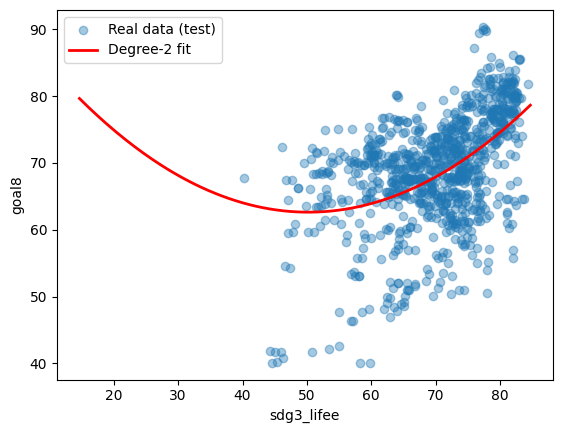

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X = dados[["sdg3_lifee"]]
y = dados[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# --- HYPERPARAMETER TUNING: DEGREE SELECTION ---
# This loop compares how the polynomial degree affects model performance on unseen data.
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train)
    X_test_p  = poly.transform(X_test)
    m = LinearRegression().fit(X_train_p, y_train)

     # INDICATOR: Test R² (Coefficient of Determination on Test Set)
    # - Evaluates model performance on the test data.
    # - If the test R² decreases as the degree increases, this may indicate overfitting.
    print("degree", degree, "-> test R2 =", round(r2_score(y_test, m.predict(X_test_p)), 3))

# fit the degree-2 model and draw its curve over the data
# NOTE: Degree 2 was chosen for the visualization because it is a simple non-linear model.
poly2 = PolynomialFeatures(degree=2, include_bias=False)
reg_poly = LinearRegression().fit(poly2.fit_transform(X_train), y_train)
plt.scatter(X_test, y_test, alpha=0.4, label="Real data (test)")

# --- NON-LINEAR VISUAL ANALYSIS ---
# Instead of a straight line, the model plots a parabolic curve to represent a possible curved relationship.
xx = pd.DataFrame({"sdg3_lifee": np.linspace(X["sdg3_lifee"].min(), X["sdg3_lifee"].max(), 200)})
plt.plot(xx["sdg3_lifee"], reg_poly.predict(poly2.transform(xx)), color="red", lw=2, label="Degree-2 fit")
plt.xlabel("sdg3_lifee"); plt.ylabel("goal8"); plt.legend(); plt.show()

# --- FINAL JUSTIFICATION FOR THE POLYNOMIAL REGRESSION INDICATORS ---
# For this non-linear model, test R² was compared across different polynomial degrees:
# 1. Test R² helps us evaluate whether increasing the degree improves prediction on unseen data.
# 2. The degree-2 curve helps us visualize a possible non-linear relationship between life expectancy and goal8.
# This approach allows us to compare a straight-line model with more flexible polynomial models.


### Answer

Increasing the polynomial degree improved the test R², but only modestly. The test R² increased from 0.227 for degree 1 to 0.242 for degree 2 and 0.247 for degree 3. Therefore, the curved models captured the relationship slightly better than the straight-line model, but the improvement was not very large.

Using a very high polynomial degree can lead to overfitting. In that case, the model may fit random noise and small variations in the training data instead of the general relationship. As a result, it may perform well on the training data but poorly on new test data.

###Your turn

In [ ]:
for degree in range(1, 13):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)
    m = LinearRegression().fit(X_train_p, y_train)

    print("degree", degree,
        "-> train R2 =", round(r2_score(y_train, m.predict(X_train_p)), 3),
        "test R2 =", round(r2_score(y_test, m.predict(X_test_p)), 3))

degree 1 -> train R2 = 0.212 test R2 = 0.227
degree 2 -> train R2 = 0.244 test R2 = 0.242
degree 3 -> train R2 = 0.25 test R2 = 0.247
degree 4 -> train R2 = 0.254 test R2 = 0.256
degree 5 -> train R2 = 0.257 test R2 = 0.259
degree 6 -> train R2 = 0.259 test R2 = 0.263
degree 7 -> train R2 = 0.26 test R2 = 0.266
degree 8 -> train R2 = 0.26 test R2 = 0.266
degree 9 -> train R2 = 0.258 test R2 = 0.265
degree 10 -> train R2 = 0.258 test R2 = 0.264
degree 11 -> train R2 = 0.258 test R2 = 0.263
degree 12 -> train R2 = 0.258 test R2 = 0.263


The test R² improved up to degrees 7 and 8, where it reached its highest value of 0.266. From degree 9 onward, the test R² stopped improving and remained between 0.263 and 0.265.

Therefore, increasing the degree beyond 8 did not improve the model's performance on new data. The train and test R² values remained close, with the test R² slightly higher. This does not show strong overfitting, but it suggests that the higher-degree models add complexity without improving generalization.

# Task 5 - KNN regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

preds = ["sdg3_lifee", "sdg9_articles", "sdg5_lfpr"]
X = dados[preds]
y = dados[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# --- DATA NORMALIZATION (StandardScaler) ---
# KNN relies on calculating Euclidean distances between data points.
# Scaling features to have a mean of 0 and a standard deviation of 1 is important;
# otherwise, features with larger numerical ranges can have more influence on the distances.
scaler = StandardScaler().fit(X_train)          # fit on train only
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# --- HYPERPARAMETER TUNING: NEIGHBORS SELECTION (K) ---
# This loop evaluates how the choice of 'k' affects the model's performance on new data.
for k in range(1, 21):

    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train_s, y_train)

    # Making predictions for both sets
    train_pred = knn.predict(X_train_s)
    test_pred = knn.predict(X_test_s)

    # INDICATOR 1 & 2: Train R² vs Test R² Comparison
    # - A small K can capture local noise, producing a high Train R² but a lower Test R².
    # - Comparing the results for different K values helps identify possible overfitting
    #   at small K values and possible underfitting at larger K values.
    r2_train = round(r2_score(y_train, train_pred), 3)
    r2_test = round(r2_score(y_test, test_pred), 3)

    # INDICATOR 3: RMSE (Root Mean Squared Error)
    # - Measures prediction error on the test set while giving more weight to larger errors.
    rmse_test = round(mean_squared_error(y_test, test_pred) ** 0.5, 2)

    print(f"k = {k:2d} -> "
        f"Train R² = {r2_train} | "
        f"Test R² = {r2_test} | "
        f"RMSE = {rmse_test}")

# --- FINAL JUSTIFICATION FOR THE KNN REGRESSION INDICATORS ---
# For this distance-based algorithm, feature scaling, Train vs Test R², and RMSE
# provide complementary information:
# 1. StandardScaler places the predictors on comparable scales for the distance calculation.
# 2. Comparing Train R² and Test R² helps identify possible overfitting or underfitting.
# 3. RMSE measures the prediction error and allows comparison with the previous models.

k =  1 -> Train R² = 1.0 | Test R² = 0.49 | RMSE = 5.93
k =  2 -> Train R² = 0.87 | Test R² = 0.563 | RMSE = 5.49
k =  3 -> Train R² = 0.821 | Test R² = 0.614 | RMSE = 5.16
k =  4 -> Train R² = 0.782 | Test R² = 0.622 | RMSE = 5.11
k =  5 -> Train R² = 0.753 | Test R² = 0.618 | RMSE = 5.13
k =  6 -> Train R² = 0.73 | Test R² = 0.617 | RMSE = 5.14
k =  7 -> Train R² = 0.708 | Test R² = 0.61 | RMSE = 5.18
k =  8 -> Train R² = 0.688 | Test R² = 0.604 | RMSE = 5.23
k =  9 -> Train R² = 0.677 | Test R² = 0.602 | RMSE = 5.23
k = 10 -> Train R² = 0.665 | Test R² = 0.595 | RMSE = 5.28
k = 11 -> Train R² = 0.654 | Test R² = 0.588 | RMSE = 5.33
k = 12 -> Train R² = 0.64 | Test R² = 0.582 | RMSE = 5.37
k = 13 -> Train R² = 0.629 | Test R² = 0.575 | RMSE = 5.41
k = 14 -> Train R² = 0.622 | Test R² = 0.565 | RMSE = 5.47
k = 15 -> Train R² = 0.612 | Test R² = 0.561 | RMSE = 5.5
k = 16 -> Train R² = 0.605 | Test R² = 0.558 | RMSE = 5.52
k = 17 -> Train R² = 0.597 | Test R² = 0.552 | RMSE = 5.56
k = 1

### Answer

KNN performed better than both linear regression models. The best result was obtained with `k = 4`, with a test R² of 0.622 and an RMSE of 5.11. In comparison, the simple linear regression had a test R² of 0.227, and the multiple linear regression had a test R² of 0.340.

KNN can perform better because it is a flexible, non-parametric method. Instead of assuming a straight-line relationship, it predicts `goal8` using nearby observations and can capture more complex and nonlinear patterns in the data.

KNN needs feature scaling because it calculates distances between observations. Without scaling, variables with larger numerical ranges can dominate the distance calculation. Linear regression does not depend on distances, so scaling is not required, although changing the scale of a predictor changes the numerical value of its coefficient.

###Your turn

In [ ]:
for k in [5, 10, 20]:
    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    pred = knn.predict(X_test)
    print("k =", k, "-> R2 =", round(r2_score(y_test, pred), 3),
          " RMSE =", round(mean_squared_error(y_test, pred)**0.5, 2))

k = 5 -> R2 = 0.542  RMSE = 5.62
k = 10 -> R2 = 0.533  RMSE = 5.67
k = 20 -> R2 = 0.508  RMSE = 5.83


Without scaling, the KNN model performed worse. For `k = 5`, the test R² decreased from 0.618 with scaling to 0.542 without scaling. The RMSE also increased from 5.13 to 5.62.

The scale of the columns matters because KNN uses distances to identify the nearest observations. A predictor with a larger numerical range can have a greater influence on the distance calculation, even if it is not more important for predicting `goal8`. Scaling places the predictors on comparable scales, allowing each one to contribute more equally to the distance calculation.

#Task 6 - Compare the models

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

    *   Após executar, siga as instruções para autenticar sua conta do Google.
    *   Uma vez montado, seus arquivos estarão acessíveis através do caminho `/content/drive/MyDrive/`. Por exemplo, se seu arquivo 'sdg8_dataset_final.xlsx' estiver na raiz do seu Google Drive, o caminho completo será `'/content/drive/MyDrive/sdg8_dataset_final.xlsx'`.

In [ ]:
r2_simple = 0.227
r2_multiple = 0.340
r2_poly = 0.242
r2_knn = 0.622

rmse_simple = 7.30
rmse_multiple = 6.74
rmse_poly = 7.23
rmse_knn = 5.11

results = pd.DataFrame({
    "Model": ["Simple linear", "Multiple linear", "Polynomial (degree 2)", "KNN (k = 4)"],
    "Test R2": [r2_simple, r2_multiple, r2_poly, r2_knn],
    "Test RMSE": [rmse_simple, rmse_multiple, rmse_poly, rmse_knn],})

results

# --- FINAL TASK CONCLUSIONS & RESULTS INTERPRETATION ---
# 1. THE BEST PREDICTIVE MODEL:
#    - KNN achieved the highest Test R², with a value of 0.622.
#    - It also achieved the lowest RMSE, with a value of 5.11.
#
# 2. LINEAR AND POLYNOMIAL MODELS:
#    - The multiple linear regression performed better than the simple linear regression.
#    - The degree-2 polynomial model slightly improved the Test R² compared with the simple linear model,
#      but its performance was lower than the multiple linear regression and KNN.
#
# 3. WHY KNN PERFORMED BETTER:
#    - KNN is more flexible and can capture local and non-linear relationships.
#    - However, these results show better predictive performance and do not prove the exact reason
#      for the relationships observed in the data.

,Model,Test R2,Test RMSE
0,Simple linear,0.227,7.30
1,Multiple linear,0.340,6.74
2,Polynomial (degree 2),0.242,7.23
3,KNN (k = 4),0.622,5.11


### Answer
The KNN model predicts `goal8` best because it has the highest test R², 0.622, and the lowest RMSE, 5.11.

The simple linear regression is the easiest model to explain because it uses only one predictor and one coefficient.

R² shows how much of the variation in `goal8` is explained by the model. A higher R² means better predictive performance.

MAE is the mean absolute error. It is in the same unit as `goal8`, so it is easy to understand.

MSE is the mean squared error. Large errors have more influence because the errors are squared.

RMSE is the root mean squared error. It is also in the same unit as `goal8` and represents a typical prediction error.

RMSE is usually larger than MAE because it gives more weight to large errors. The simplified models explained only part of the variation in `goal8`. The multiple linear regression performed better than the simple linear and degree-2 polynomial models, but KNN had the best predictive performance.

### Your turn

We would choose the multiple linear regression model. It is not the most accurate model, but it is easier to explain than KNN. It shows how each predictor is related to `goal8` through its coefficient. This is important for a policymaker because the model is more transparent and can help explain which factors are associated with higher SDG 8 scores.

# Taks 7 - Use all the indicators (bonus)

In [ ]:


from sklearn.impute import SimpleImputer

all_preds = [c for c in base.columns
             if c not in ["id", "Country", "indexreg", "year", TARGET]
             and pd.api.types.is_numeric_dtype(base[c])]

X = base[all_preds]
y = base[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3)

# --- DATA IMPUTATION (SimpleImputer) ---
# Because many numeric predictors contain missing values, removing incomplete
# observations would substantially reduce the available sample size.
# Median imputation is adopted because it is robust to extreme values and
# preserves the dataset without assuming a normal distribution.
# To avoid Data Leakage, the imputer is fitted exclusively on the training set.
imputer = SimpleImputer(strategy="median").fit(X_train)

X_train_i = imputer.transform(X_train)
X_test_i = imputer.transform(X_test)

# --- HIGH-DIMENSIONAL LINEAR REGRESSION ---
# This model incorporates every available numeric predictor to evaluate whether
# increasing the amount of information improves predictive performance.
# BEST INDICATOR: Test R²
# - Measures the proportion of variance explained on unseen observations.
# - Using all predictors may increase explanatory power, although highly
#   correlated variables can reduce model stability and interpretability.

lr = LinearRegression().fit(X_train_i, y_train)

print(    "Linear (all) R2 =",
    round(r2_score(y_test, lr.predict(X_test_i)), 3))

# --- HIGH-DIMENSIONAL KNN REGRESSION ---
# KNN is entirely based on distance calculations. Therefore, feature
# standardization is important so that predictors measured on different
# numerical scales are comparable when identifying nearest neighbors.
scaler = StandardScaler().fit(X_train_i)

knn = KNeighborsRegressor(n_neighbors=10).fit(
    scaler.transform(X_train_i),
    y_train
)

# BEST INDICATOR: Test R²
# - Evaluates the predictive performance of a distance-based model after
#   feature standardization.
# - Comparing its Test R² with Linear Regression shows whether a
#   non-parametric approach better captures relationships among all
#   available predictors.

print(
    "KNN (all, scaled) R2 =",
    round(
        r2_score(
            y_test,
            knn.predict(scaler.transform(X_test_i))
        ),
        3
    )
)

# --- FINAL JUSTIFICATION FOR THE IMPUTATION AND ALL-PREDICTOR INDICATORS ---
# The selected indicators provide a reliable framework for evaluating
# high-dimensional regression models:
#
# 1. Median Imputation preserves more observations while reducing the
#    influence of extreme values during missing-data treatment.
#
# 2. Fitting both the Imputer and the StandardScaler only on the training set
#    helps prevent Data Leakage, ensuring that the test data is not used
#    during model preparation.
#
# 3. Test R² offers a consistent basis for comparing Linear Regression and
#    KNN using all available numeric predictors, indicating whether the added
#    information improves predictive accuracy or whether increased feature
#    dimensionality limits model generalization.



Linear (all) R2 = 0.541
KNN (all, scaled) R2 = 0.89


### Answer
The R² of the linear model increased from 0.227 to 0.541, an increase of 0.314. The R² of KNN increased from 0.622 to 0.890, an increase of 0.268. Therefore, using all available predictors provided additional information and improved the predictive performance of both models.

The advantage of using all predictors is the higher prediction accuracy. However, the models become more difficult to interpret because it is harder to understand the role of each predictor.

###Your turn

In [ ]:
print("Rows after dropna:", len(base[all_preds].dropna()))
print("Rows in full dataset:", len(base))

Rows after dropna: 44
Rows in full dataset: 4925


We had to impute the missing values because using `.dropna()` would remove almost all the data. The full dataset has 4,925 rows, but `base[all_preds].dropna()` keeps only 44 rows. This happens because, with 55 predictors, a row is removed if it has a missing value in any one of them. Therefore, imputation allows us to keep most of the dataset and replace the missing values with the median calculated from the training data.

# Reflection questions

**1. How did we select the predictors?**
We selected predictors that had relatively strong positive or negative correlations with `goal8`. We also checked the correlations among the predictors. When two predictors were strongly correlated with each other, such as life expectancy and poverty, we considered that they could provide similar information. We kept life expectancy because it had the strongest correlation with `goal8`.

**2. What does an R² around 0.2 tell us?**
An R² around 0.2 means that the model explains about 20% of the variation in `goal8`. This can be improved by adding more relevant predictors or by using a more flexible model, such as KNN. In our results, both approaches increased the R².

**3. What is one advantage of each method?**
One advantage of linear regression is that it is easy to understand and explain because we can interpret its coefficients. One advantage of KNN is that it can capture more complex relationships without assuming that they are linear, and it produced better predictive performance in our analysis.